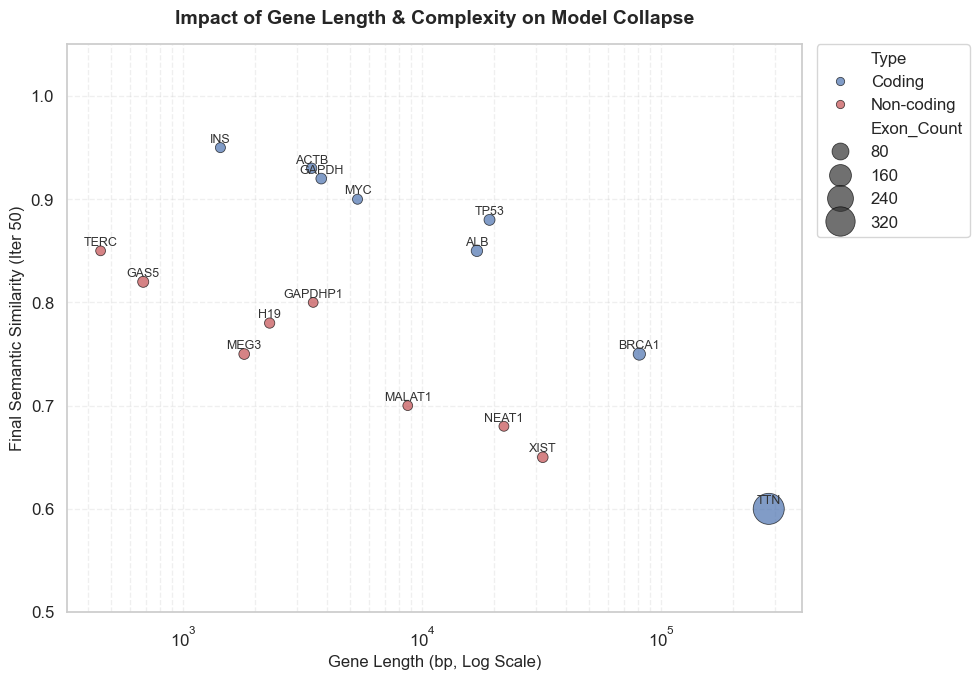

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ----------------------------------------------------------------------------------
# 1. 데이터 준비 (가상 데이터: 16개 유전자)
# ----------------------------------------------------------------------------------
# 실제 데이터가 있다면 이 부분을 pd.read_csv() 등으로 대체하세요.
data = {
    'Gene': ['INS', 'GAPDH', 'ACTB', 'TP53', 'MYC', 'ALB', 'BRCA1', 'TTN',
             'GAPDHP1', 'GAS5', 'H19', 'MEG3', 'TERC', 'MALAT1', 'XIST', 'NEAT1'],
    'Type': ['Coding']*8 + ['Non-coding']*8,
    'Length_bp': [1431, 3783, 3447, 19149, 5366, 16961, 81155, 282496, 
                  3500, 680, 2300, 1800, 451, 8708, 32000, 22000],  # 실제 길이 대략 반영
    'Exon_Count': [3, 9, 6, 11, 3, 15, 24, 363, 
                   1, 12, 5, 9, 1, 1, 8, 2],  # Non-coding은 엑손 개념이 다르지만 편의상 복잡도로 가정
    # 붕괴도 시뮬레이션: 길고 엑손 많을수록 Sim 낮음 + Non-coding이 더 낮음
    'Final_Similarity': [0.95, 0.92, 0.93, 0.88, 0.90, 0.85, 0.75, 0.60, 
                         0.80, 0.82, 0.78, 0.75, 0.85, 0.70, 0.65, 0.68]
}

df = pd.DataFrame(data)

# ----------------------------------------------------------------------------------
# 2. 버블 차트 그리기
# ----------------------------------------------------------------------------------
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid", font_scale=1.1)

# Scatterplot 그리기
# hue: 색상 (Coding/Non-coding)
# size: 크기 (Exon Count)
# sizes: 원의 최소-최대 크기 조절
scatter = sns.scatterplot(
    data=df, 
    x='Length_bp', 
    y='Final_Similarity',
    hue='Type', 
    size='Exon_Count',
    sizes=(50, 500), # 원 크기 범위 (조절 가능)
    palette={'Coding': '#4C72B0', 'Non-coding': '#C44E52'},
    alpha=0.7, 
    edgecolor='black'
)

# 3. 로그 스케일 적용 (길이 편차가 크므로)
plt.xscale('log') 

# 4. 유전자 이름 텍스트 달기 (Annotation)
# 겹침 방지를 위해 adjust_text 라이브러리를 쓰면 좋지만, 기본 방식으로 구현
for i in range(df.shape[0]):
    plt.text(
        df.Length_bp[i], 
        df.Final_Similarity[i]+0.005, # 점보다 살짝 위에 표시
        df.Gene[i], 
        fontsize=9, 
        ha='center', 
        color='#333333'
    )

# 5. 스타일링
plt.title('Impact of Gene Length & Complexity on Model Collapse', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Gene Length (bp, Log Scale)', fontsize=12)
plt.ylabel('Final Semantic Similarity (Iter 50)', fontsize=12)
plt.ylim(0.5, 1.05)
plt.grid(True, which="both", ls="--", alpha=0.3)

# 범례 정리 (위치 조정)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

plt.tight_layout()
plt.show()

/var/folders/wm/m60tntks4_55jf79w27yb1t40000gn/T/ipykernel_70399/2527341635.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/var/folders/wm/m60tntks4_55jf79w27yb1t40000gn/T/ipykernel_70399/2527341635.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


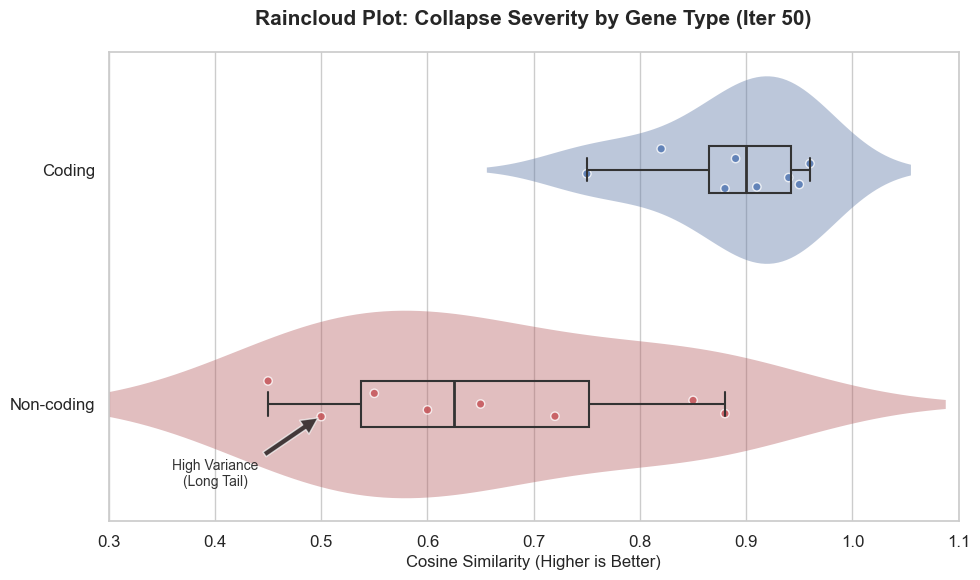

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ----------------------------------------------------------------------------------
# 1. 데이터 준비 (16개 유전자, Iteration 50 기준)
# ----------------------------------------------------------------------------------
# Coding: 대체로 잘 버팀 (0.8 ~ 1.0 사이, 편차 작음)
# Non-coding: 어떤 건 잘 버티고 어떤 건 망가짐 (0.4 ~ 0.9 사이, 편차 큼 -> 꼬리가 김)
data = {
    'Gene': ['INS', 'GAPDH', 'ACTB', 'TP53', 'MYC', 'ALB', 'BRCA1', 'TTN',
             'GAPDHP1', 'GAS5', 'H19', 'MEG3', 'TERC', 'MALAT1', 'XIST', 'NEAT1'],
    'Type': ['Coding']*8 + ['Non-coding']*8,
    'Final_Similarity': [0.96, 0.94, 0.95, 0.89, 0.91, 0.88, 0.82, 0.75, 
                         0.65, 0.85, 0.72, 0.55, 0.88, 0.45, 0.50, 0.60] 
}
df = pd.DataFrame(data)

# ----------------------------------------------------------------------------------
# 2. Raincloud Plot 그리기 (Layering Technique)
# ----------------------------------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid", font_scale=1.1)

# 색상 팔레트 설정
my_pal = {"Coding": "#4C72B0", "Non-coding": "#C44E52"}

# Layer 1: ☁️ 구름 (Violin Plot) - 분포 모양
# inner=None: 안에 박스플롯을 그리지 않음 (따로 그릴 거라)
# alpha: 투명도 조절
ax = sns.violinplot(
    data=df, y="Type", x="Final_Similarity", 
    palette=my_pal, inner=None, linewidth=0, alpha=0.4, orient="h"
)

# Layer 2: 🌧️ 비 (Strip Plot) - 개별 데이터 점
# jitter=True: 점들이 겹치지 않게 위아래로 흩뿌림
sns.stripplot(
    data=df, y="Type", x="Final_Similarity", 
    palette=my_pal, size=6, jitter=True, alpha=0.8, orient="h", edgecolor="white", linewidth=1
)

# Layer 3: ☂️ 우산 (Box Plot) - 요약 통계량 (중앙값, 사분위수)
# width: 박스 두께를 얇게 해서 구름을 가리지 않게 함
# boxprops={'facecolor':'none'}: 박스 내부를 투명하게 해서 뒤가 보이게 함
sns.boxplot(
    data=df, y="Type", x="Final_Similarity", 
    width=0.2, showfliers=False, # 이상치는 strip plot이 보여주므로 제외
    boxprops={'facecolor':'none', 'edgecolor':'#333333', 'linewidth': 1.5},
    whiskerprops={'color':'#333333', 'linewidth': 1.5},
    capprops={'color':'#333333', 'linewidth': 1.5},
    medianprops={'color':'#333333', 'linewidth': 2},
    zorder=10, orient="h"
)

# ----------------------------------------------------------------------------------
# 3. 스타일링 및 해석용 주석
# ----------------------------------------------------------------------------------
plt.title('Raincloud Plot: Collapse Severity by Gene Type (Iter 50)', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Cosine Similarity (Higher is Better)', fontsize=12)
plt.ylabel('')
plt.xlim(0.3, 1.1)

# 해석 가이드 (Annotation)
# Non-coding 쪽의 긴 꼬리(Long Tail)를 가리킴
plt.annotate(
    'High Variance\n(Long Tail)', 
    xy=(0.50, 1.05), xytext=(0.40, 1.35),
    arrowprops=dict(facecolor='black', shrink=0.05, alpha=0.7),
    fontsize=10, color='#333333', ha='center'
)

plt.tight_layout()
plt.show()